# Paper figures

Nine figures and Table 1 for the CSCE 723 paper, written to
`results/noise_maneuver_grid/figures_paper` as 600 dpi PNG and vector PDF, plus one
discussion figure for talks. Everything reads the analysis and cache outputs on disk;
nothing here touches Smith's code.

Run the cells in order. It takes a few seconds.

## Setup

Style and the save helper. Colours are the Okabe-Ito set, which survives the common types of
colour blindness and prints fine in greyscale.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GRID = PROJECT_ROOT / "results/noise_maneuver_grid"
ANALYSIS = GRID / "analysis"
CACHE = GRID / "paper_cache"
RESIDUALS = GRID / "residual_cache"
FIGURES = GRID / "figures_paper"
FIGURES.mkdir(parents=True, exist_ok=True)

# Okabe-Ito, colourblind safe and greyscale safe.
ORANGE, SKY, GREEN, YELLOW = "#E69F00", "#56B4E9", "#009E73", "#F0E442"
BLUE, VERMILION, PURPLE, BLACK = "#0072B2", "#D55E00", "#CC79A7", "#000000"
GREY = "#7F7F7F"

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8.5,
    "axes.titlesize": 8.5,
    "axes.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=[BLUE, ORANGE, GREEN, VERMILION, SKY, PURPLE, YELLOW]),
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "legend.fontsize": 7.5,
    "legend.frameon": False,
    "lines.linewidth": 1.3,
    "lines.markersize": 3.5,
    "grid.linewidth": 0.5,
    "grid.alpha": 0.35,
})

POLICY_LABEL = {"advanced_greedy": "Advanced greedy", "frozen_cnnv2_ppo": "Frozen CNNv2 PPO"}
# Null percentiles for a three component innovation.
CHI2_P95, CHI2_P99 = 7.814727903251179, 11.344866730144373
COLUMN_WIDTH, DOUBLE_WIDTH = 3.5, 7.2   # inches, single and double journal column


def panel_label(ax, letter, dx=0, dy=9):
    """Bold panel letter, anchored above the left edge of the axes so nothing can overlap it."""
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction", xytext=(dx, dy),
                textcoords="offset points", fontsize=10, fontweight="bold",
                va="bottom", ha="left")


def save(fig, name):
    for extension in ("png", "pdf"):
        fig.savefig(FIGURES / f"{name}.{extension}")
    print(f"saved {name}.png and {name}.pdf")


cell_summary = pd.read_csv(ANALYSIS / "cell_summary.csv")
paired = pd.read_csv(ANALYSIS / "paired_effects.csv")
dose = pd.read_csv(ANALYSIS / "dose_response.csv")
nis_summary = pd.read_csv(ANALYSIS / "nis_summary.csv")
post_burn_nis = pd.read_csv(ANALYSIS / "first_post_burn_nis.csv")
ceiling = pd.read_csv(CACHE / "covariance_ceiling.csv")
episode_state = pd.read_csv(CACHE / "episode_end_state.csv")
history = np.load(CACHE / "covariance_history.npz")


def residuals(policy, condition):
    """One row per measurement Smith's filter processed, from build_residual_cache.py."""
    return dict(np.load(RESIDUALS / f"{policy}_{condition}.npz"))


print(f"{len(cell_summary)} cells, {len(dose)} maneuver events, {len(post_burn_nis)} NIS samples")

22 cells, 28000 maneuver events, 17797 NIS samples


## Table 1

The numbers the paper quotes in text. One row per maneuver condition at 10 km measurement noise,
against the matched null-burn control.

In [2]:
CONDITION_LABEL = {
    "nullburn": "No maneuver (control)",
    "random": "Isotropic, 1-100 m/s",
    "radial": "Radial, 1-100 m/s",
    "transverse": "In-track, 1-100 m/s",
    "normal": "Cross-track, 1-100 m/s",
    "finite1800s": "Finite 1800 s, 1-100 m/s",
    "stress100to2000": "Isotropic, 100-2000 m/s",
}
ORDER = list(CONDITION_LABEL)

rows = []
for policy in POLICY_LABEL:
    control = cell_summary.query(
        "policy == @policy and sigma_km == 10 and maneuver == 'nullburn'"
    ).iloc[0]
    for condition in ORDER:
        match = cell_summary.query(
            "policy == @policy and sigma_km == 10 and maneuver == @condition"
        )
        if match.empty:
            continue
        row = match.iloc[0]
        nis = nis_summary.query(
            "policy == @policy and sigma_km == 10 and maneuver == @condition "
            "and group == 'maneuvering_after_burn'"
        )
        rows.append({
            "Policy": POLICY_LABEL[policy],
            "Condition": CONDITION_LABEL[condition],
            "Episodes": int(row.episodes),
            "Tagged cov.": row.mean_final_tagged_covariance,
            "Cov. change %": 100 * (row.mean_final_tagged_covariance
                                    - control.mean_final_tagged_covariance)
                             / control.mean_final_tagged_covariance,
            "Median error (km)": row.mean_final_tagged_error_median_km,
            "Error change %": 100 * (row.mean_final_tagged_error_median_km
                                     - control.mean_final_tagged_error_median_km)
                              / control.mean_final_tagged_error_median_km,
            "Reacquired": row.mean_reacquired_fraction,
            "Post-burn NIS": float(nis.mean_nis.iloc[0]) if len(nis) else np.nan,
        })

table_one = pd.DataFrame(rows)
table_one.to_csv(FIGURES / "table1_condition_summary.csv", index=False)
table_one.style.format({
    "Tagged cov.": "{:.5f}", "Cov. change %": "{:+.2f}",
    "Median error (km)": "{:.2f}", "Error change %": "{:+,.0f}",
    "Reacquired": "{:.3f}", "Post-burn NIS": "{:.1f}",
}).hide(axis="index")

Policy,Condition,Episodes,Tagged cov.,Cov. change %,Median error (km),Error change %,Reacquired,Post-burn NIS
Advanced greedy,No maneuver (control),100,0.01146,+0.00,5.35,+0,0.297,3.0
Advanced greedy,"Isotropic, 1-100 m/s",100,0.01147,+0.10,28.81,+439,0.296,19.4
Advanced greedy,"Radial, 1-100 m/s",100,0.01146,-0.01,26.70,+399,0.297,6.5
Advanced greedy,"In-track, 1-100 m/s",100,0.01145,-0.04,25.30,+373,0.297,4.9
Advanced greedy,"Cross-track, 1-100 m/s",100,0.01150,+0.37,31.53,+490,0.293,41.4
Advanced greedy,"Finite 1800 s, 1-100 m/s",100,0.01147,+0.11,19.93,+273,0.296,10.3
Advanced greedy,"Isotropic, 100-2000 m/s",100,0.01219,+6.36,1071.84,"+19,939",0.234,1723.2
Frozen CNNv2 PPO,No maneuver (control),100,0.01033,+0.00,4.40,+0,0.706,2.8
Frozen CNNv2 PPO,"Isotropic, 1-100 m/s",100,0.01033,+0.04,24.65,+460,0.705,26.4
Frozen CNNv2 PPO,"Radial, 1-100 m/s",100,0.01033,+0.00,23.51,+434,0.705,19.9


## Figure 1

Mean covariance trace over the run, averaged across 100 episodes. Three maneuver conditions on
each panel. If the reward responded to maneuvers, the curves would separate. The largest
separation anywhere is at the end of the run and the cell prints it below.

Advanced greedy: largest separation at the end of the run +3.3%
Frozen CNNv2 PPO: largest separation at the end of the run +1.2%


saved fig1_covariance_history.png and fig1_covariance_history.pdf


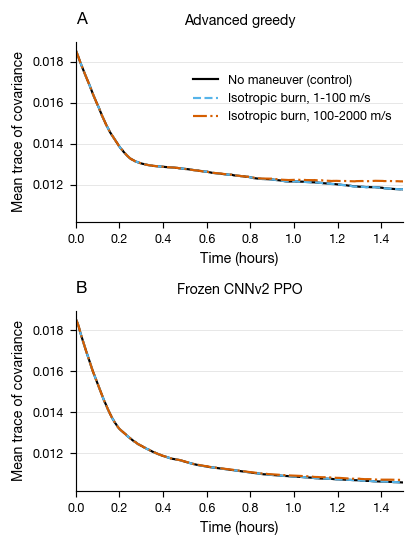

In [3]:
CURVE_STYLE = {
    "nullburn": (BLACK, "-", "No maneuver (control)"),
    "random": (SKY, "--", "Isotropic burn, 1-100 m/s"),
    "stress100to2000": (VERMILION, "-.", "Isotropic burn, 100-2000 m/s"),
}

fig, axes = plt.subplots(2, 1, figsize=(COLUMN_WIDTH, 4.6), sharey=True)
for ax, (policy, label), letter in zip(axes, POLICY_LABEL.items(), "AB"):
    for condition, (colour, dash, legend) in CURVE_STYLE.items():
        time = history[f"{policy}|{condition}|time_seconds"] / 3600.0
        curve = history[f"{policy}|{condition}|mean_all"]
        ax.plot(time, curve, color=colour, linestyle=dash, label=legend)
    control_end = history[f"{policy}|nullburn|mean_all"][-1]
    stress_end = history[f"{policy}|stress100to2000|mean_all"][-1]
    gap = 100 * (stress_end - control_end) / control_end
    print(f"{label}: largest separation at the end of the run {gap:+.1f}%")
    ax.set_title(label, pad=10)
    ax.set_xlabel("Time (hours)")
    ax.set_xlim(0, time[-1])
    ax.grid(axis="y")
    panel_label(ax, letter)

for ax in axes:
    ax.set_ylabel("Mean trace of covariance")
axes[0].legend(loc="upper right", bbox_to_anchor=(1.0, 0.88))
fig.tight_layout()
save(fig, "fig1_covariance_history")
plt.show()

## Figure 2

Paired change from the matched control, as a percentage of the control value. Panel A is the
reward quantity. Panel B is the tracking error the reward stands in for. The two panels are on
very different scales, which is the whole point. Bars are 95% bootstrap intervals over 10,000
resamples.

saved fig2_paired_change_from_control.png and fig2_paired_change_from_control.pdf


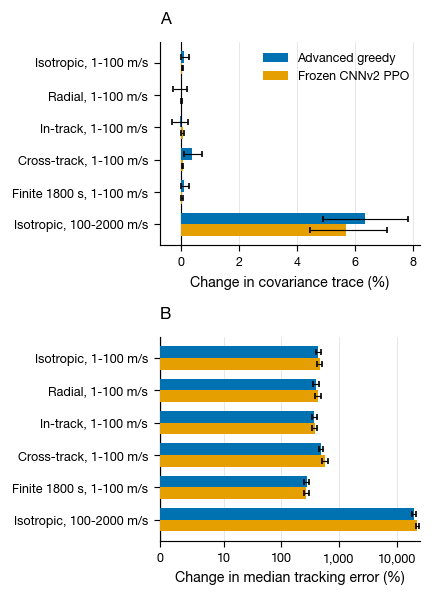

In [4]:
TREATMENTS = ["random", "radial", "transverse", "normal", "finite1800s", "stress100to2000"]
CONTRASTS = {t: f"{t}_minus_control" for t in TREATMENTS}


def paired_percent(policy, metric, baseline_column):
    control = cell_summary.query(
        "policy == @policy and sigma_km == 10 and maneuver == 'nullburn'"
    ).iloc[0][baseline_column]
    values, lows, highs = [], [], []
    for treatment in TREATMENTS:
        contrast = CONTRASTS[treatment]
        held = f"10.0|{treatment}"
        match = paired.query(
            "comparison == 'maneuver_effect' and policy == @policy "
            "and contrast == @contrast and metric == @metric and held_fixed == @held"
        )
        if match.empty:
            values.append(np.nan); lows.append(np.nan); highs.append(np.nan); continue
        row = match.iloc[0]
        values.append(100 * row.mean_paired_change / control)
        lows.append(100 * row.ci_low / control)
        highs.append(100 * row.ci_high / control)
    return np.array(values), np.array(lows), np.array(highs)


fig, axes = plt.subplots(2, 1, figsize=(COLUMN_WIDTH, 5.4), sharey=True,
                         gridspec_kw={"left": 0.28, "hspace": 0.45})
positions = np.arange(len(TREATMENTS))
height = 0.36
panels = [
    (axes[0], "final_tagged_covariance", "mean_final_tagged_covariance",
     "Change in covariance trace (%)", "A", False),
    (axes[1], "final_tagged_error_median_km", "mean_final_tagged_error_median_km",
     "Change in median tracking error (%)", "B", True),
]

for ax, metric, baseline, xlabel, letter, logscale in panels:
    for offset, (policy, colour) in zip((-height / 2, height / 2),
                                        zip(POLICY_LABEL, (BLUE, ORANGE))):
        values, lows, highs = paired_percent(policy, metric, baseline)
        errors = np.vstack([values - lows, highs - values])
        ax.barh(positions + offset, values, height=height, color=colour,
                label=POLICY_LABEL[policy], zorder=3)
        ax.errorbar(values, positions + offset, xerr=errors, fmt="none",
                    ecolor=BLACK, elinewidth=0.7, capsize=1.8, zorder=4)
    ax.axvline(0, color=BLACK, linewidth=0.7)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x")
    if logscale:
        ax.set_xscale("symlog", linthresh=10)
        ax.set_xticks([0, 10, 100, 1000, 10000])
        ax.set_xticklabels(["0", "10", "100", "1,000", "10,000"])
    panel_label(ax, letter)

axes[0].set_yticks(positions)
axes[0].set_yticklabels([CONDITION_LABEL[t] for t in TREATMENTS])
axes[0].invert_yaxis()
axes[0].legend(loc="upper right")
save(fig, "fig2_paired_change_from_control")
plt.show()

## Figure 3

The innovation does carry the maneuver signal. Panel A is the distribution of the first
normalised innovation squared after each burn for the control and the two impulsive arms, against
the chi-squared null the filter assumes. Panel B adds the finite-burn arm and gives how often that
statistic clears the 99th percentile of the null.

saved fig3_innovation_detection.png and fig3_innovation_detection.pdf


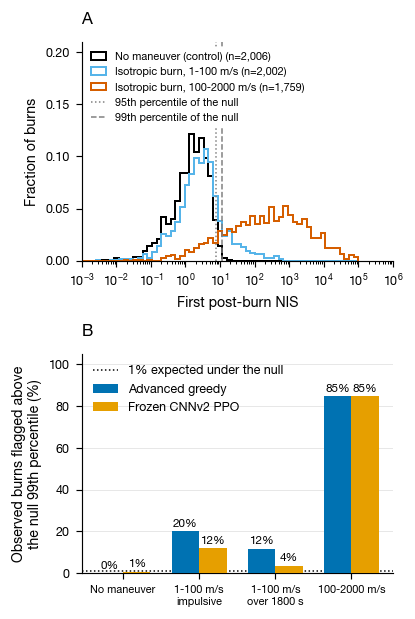

In [5]:
NIS_CONDITIONS = ["nullburn", "random", "finite1800s", "stress100to2000"]

fig, axes = plt.subplots(2, 1, figsize=(COLUMN_WIDTH, 5.2))

ax = axes[0]
bins = np.logspace(-3, 5, 60)
for condition, (colour, _, legend) in CURVE_STYLE.items():
    values = post_burn_nis.query(
        "sigma_km == 10 and maneuver == @condition"
    ).nis.to_numpy()
    values = values[values > 0]
    # Weights rather than density, so the log-spaced bins keep the high-NIS mass visible.
    ax.hist(values, bins=bins, histtype="step", color=colour, linewidth=1.2,
            weights=np.full(values.size, 1.0 / values.size),
            label=f"{legend} (n={values.size:,})")
ax.axvline(CHI2_P95, color=GREY, linestyle=":", linewidth=0.9,
           label="95th percentile of the null")
ax.axvline(CHI2_P99, color=GREY, linestyle="--", linewidth=0.9,
           label="99th percentile of the null")
ax.set_xscale("log")
ax.set_xlim(1e-3, 1e6)
ax.set_ylim(0, 0.21)
ax.set_xlabel("First post-burn NIS")
ax.set_ylabel("Fraction of burns")
# Opaque frame so the percentile lines, which span the full height, do not run through the text.
ax.legend(loc="upper left", fontsize=6.5, handlelength=1.4,
          frameon=True, framealpha=1.0, edgecolor="none")
panel_label(ax, "A")

ax = axes[1]
positions = np.arange(len(NIS_CONDITIONS))
width = 0.36
for offset, (policy, colour) in zip((-width / 2, width / 2), zip(POLICY_LABEL, (BLUE, ORANGE))):
    rates = [100 * post_burn_nis.query(
        "policy == @policy and sigma_km == 10 and maneuver == @condition"
    ).exceeds_chi2_p99.mean() for condition in NIS_CONDITIONS]
    bars = ax.bar(positions + offset, rates, width=width, color=colour,
                  label=POLICY_LABEL[policy], zorder=3)
    ax.bar_label(bars, fmt="%.0f%%", fontsize=7, padding=1.5)
ax.axhline(1.0, color=BLACK, linestyle=":", linewidth=0.9,
           label="1% expected under the null")
ax.set_xticks(positions)
ax.set_xticklabels(["No maneuver", "1-100 m/s\nimpulsive", "1-100 m/s\nover 1800 s",
                    "100-2000 m/s"], fontsize=6.5, linespacing=1.3)
ax.set_ylabel("Observed burns flagged above\nthe null 99th percentile (%)")
ax.set_ylim(0, 105)
ax.grid(axis="y")
ax.legend(loc="upper left")
panel_label(ax, "B")

fig.tight_layout()
save(fig, "fig3_innovation_detection")
plt.show()

## Figure 4

Dose response over three orders of magnitude of burn size. The innovation scales with the burn.
The covariance does not, because the update subtracts a gain term that never reads the
measurement value.

saved fig4_dose_response.png and fig4_dose_response.pdf


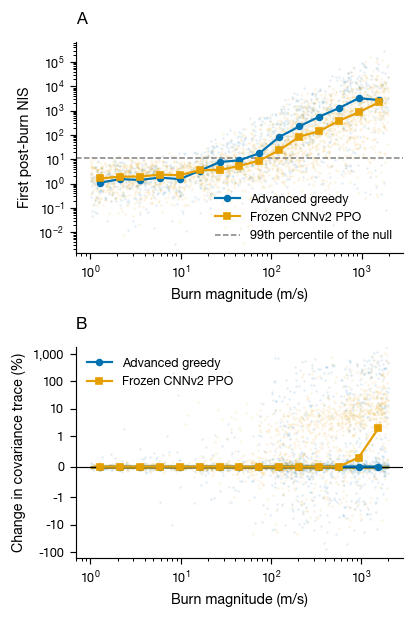

In [6]:
def binned_median(x, y, edges):
    index = np.digitize(x, edges) - 1
    centres, medians = [], []
    for bucket in range(len(edges) - 1):
        mask = index == bucket
        if mask.sum() >= 20:
            centres.append(np.sqrt(edges[bucket] * edges[bucket + 1]))
            medians.append(np.median(y[mask]))
    return np.array(centres), np.array(medians)


edges = np.logspace(0, np.log10(2000), 16)
fig, axes = plt.subplots(2, 1, figsize=(COLUMN_WIDTH, 5.2))

ax = axes[0]
for policy, colour, marker in zip(POLICY_LABEL, (BLUE, ORANGE), ("o", "s")):
    sample = post_burn_nis.query(
        "policy == @policy and sigma_km == 10 and maneuver in ['random', 'stress100to2000']"
    )
    x, y = sample.delta_v_magnitude_mps.to_numpy(), sample.nis.to_numpy()
    keep = y > 0
    ax.scatter(x[keep], y[keep], s=2, alpha=0.12, color=colour, linewidths=0)
    cx, cy = binned_median(x[keep], y[keep], edges)
    ax.plot(cx, cy, color=colour, marker=marker, label=POLICY_LABEL[policy], zorder=3)
ax.axhline(CHI2_P99, color=GREY, linestyle="--", linewidth=0.9,
           label="99th percentile of the null")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Burn magnitude (m/s)")
ax.set_ylabel("First post-burn NIS")
ax.legend(loc="lower right")
panel_label(ax, "A")

ax = axes[1]
for policy, colour, marker in zip(POLICY_LABEL, (BLUE, ORANGE), ("o", "s")):
    sample = dose.query(
        "policy == @policy and sigma_km == 10 and maneuver in ['random', 'stress100to2000']"
    )
    x = sample.delta_v_magnitude_mps.to_numpy()
    y = 100 * sample.final_trace_change.to_numpy() / sample.final_trace_control.to_numpy()
    ax.scatter(x, y, s=2, alpha=0.12, color=colour, linewidths=0)
    cx, cy = binned_median(x, y, edges)
    ax.plot(cx, cy, color=colour, marker=marker, label=POLICY_LABEL[policy], zorder=3)
ax.axhline(0, color=BLACK, linewidth=0.7)
ax.set_xscale("log")
# Symlog y keeps the flat median visible beside the large single-object excursions.
ax.set_yscale("symlog", linthresh=1)
ax.set_yticks([-100, -10, -1, 0, 1, 10, 100, 1000])
ax.set_yticklabels(["-100", "-10", "-1", "0", "1", "10", "100", "1,000"])
ax.set_xlabel("Burn magnitude (m/s)")
ax.set_ylabel("Change in covariance trace (%)")
ax.legend(loc="upper left")
panel_label(ax, "B")

fig.tight_layout()
save(fig, "fig4_dose_response")
plt.show()

## Figure 5

Why the primary condition cannot produce custody loss. Panel A is how far a burn moves an object
by the end of the run against the sensor half field of view. The median burn only crosses that
threshold near 563 m/s, far above the 1 to 100 m/s primary band, and the cell prints the crossing
below. Panel B is the fraction of tagged objects reacquired after the burn.

median burn leaves the field of view near 563 m/s


saved fig5_custody_geometry.png and fig5_custody_geometry.pdf


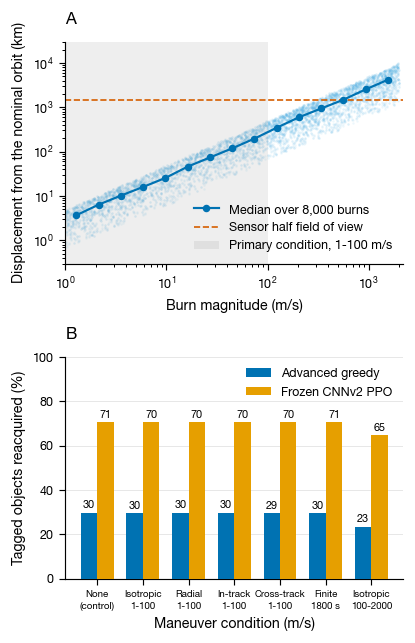

In [7]:
# A 4 degree field of view at GEO subtends about 1467 km at the half angle.
FOV_HALF_WIDTH_KM = 1467.0

fig, axes = plt.subplots(2, 1, figsize=(COLUMN_WIDTH, 5.4))

ax = axes[0]
# Displacement depends on the burn and the coast time, not the policy, so the arms are pooled.
sample = dose.query("sigma_km == 10 and maneuver in ['random', 'stress100to2000']")
x = sample.delta_v_magnitude_mps.to_numpy()
y = sample.final_nominal_truth_offset_km.to_numpy()
ax.scatter(x, y, s=2, alpha=0.10, color=SKY, linewidths=0)
cx, cy = binned_median(x, y, edges)
ax.plot(cx, cy, color=BLUE, marker="o", zorder=3,
        label=f"Median over {len(sample):,} burns")
ax.axhline(FOV_HALF_WIDTH_KM, color=VERMILION, linestyle="--", linewidth=1.0,
           label="Sensor half field of view")
ax.axvspan(1, 100, color=GREY, alpha=0.13, lw=0, label="Primary condition, 1-100 m/s")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(1, 2200)
ax.set_ylim(3e-1, 3e4)
crossing = cx[np.searchsorted(cy, FOV_HALF_WIDTH_KM)]
print(f"median burn leaves the field of view near {crossing:.0f} m/s")
ax.set_xlabel("Burn magnitude (m/s)")
ax.set_ylabel("Displacement from the nominal orbit (km)")
ax.legend(loc="lower right")
panel_label(ax, "A")

ax = axes[1]
positions = np.arange(len(ORDER))
width = 0.36
for offset, (policy, colour) in zip((-width / 2, width / 2), zip(POLICY_LABEL, (BLUE, ORANGE))):
    values = []
    for condition in ORDER:
        match = cell_summary.query(
            "policy == @policy and sigma_km == 10 and maneuver == @condition"
        )
        values.append(100 * match.mean_reacquired_fraction.iloc[0] if len(match) else np.nan)
    bars = ax.bar(positions + offset, values, width=width, color=colour,
                  label=POLICY_LABEL[policy], zorder=3)
    ax.bar_label(bars, fmt="%.0f", fontsize=6.5, padding=1.5)
SHORT_LABEL = {
    "nullburn": "None\n(control)", "random": "Isotropic\n1-100",
    "radial": "Radial\n1-100", "transverse": "In-track\n1-100",
    "normal": "Cross-track\n1-100", "finite1800s": "Finite\n1800 s",
    "stress100to2000": "Isotropic\n100-2000",
}
ax.set_xticks(positions)
ax.set_xticklabels([SHORT_LABEL[c] for c in ORDER], fontsize=5.8, linespacing=1.3)
ax.set_xlabel("Maneuver condition (m/s)")
ax.set_ylabel("Tagged objects reacquired (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y")
ax.legend(loc="upper right")
panel_label(ax, "B")

fig.tight_layout()
save(fig, "fig5_custody_geometry")
plt.show()

## Figure 6

The ceiling. The only route a maneuver has left to the covariance is stopping an object
from being observed, so the most the metric can move is the catalogue mean with every
tagged object unseen. The same burns moved median tracking error by roughly +20,000
percent, printed below the figure.

Advanced greedy: median tracking error over the same burns +19,939%
Frozen CNNv2 PPO: median tracking error over the same burns +22,672%
saved fig6_covariance_ceiling.png and fig6_covariance_ceiling.pdf


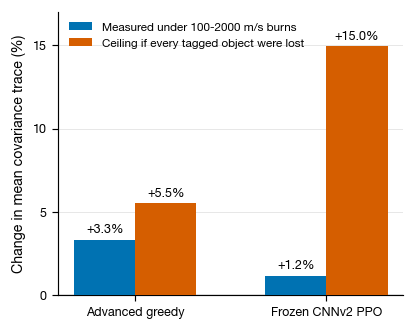

In [8]:
fig, ax = plt.subplots(figsize=(COLUMN_WIDTH, 2.8))
positions = np.arange(len(POLICY_LABEL))
width = 0.32

def percent_change(policy, condition, column):
    baseline = ceiling.query(
        "policy == @policy and condition == 'nullburn'"
    ).observed_catalog_mean.iloc[0]
    value = ceiling.query("policy == @policy and condition == @condition")[column].iloc[0]
    return 100 * (value / baseline - 1)

series = [
    ("Measured under 100-2000 m/s burns", "observed_catalog_mean", BLUE, -width / 2),
    ("Ceiling if every tagged object were lost", "ceiling_catalog_mean", VERMILION, width / 2),
]
for legend, column, colour, offset in series:
    values = [percent_change(p, "stress100to2000", column) for p in POLICY_LABEL]
    bars = ax.bar(positions + offset, values, width=width, color=colour, label=legend, zorder=3)
    ax.bar_label(bars, fmt="%+.1f%%", fontsize=7.5, padding=2)

# What the same burns did to the quantity the reward is standing in for.
for index, policy in enumerate(POLICY_LABEL):
    control = cell_summary.query(
        "policy == @policy and sigma_km == 10 and maneuver == 'nullburn'"
    ).mean_final_tagged_error_median_km.iloc[0]
    stress = cell_summary.query(
        "policy == @policy and sigma_km == 10 and maneuver == 'stress100to2000'"
    ).mean_final_tagged_error_median_km.iloc[0]
    print(f"{POLICY_LABEL[policy]}: median tracking error over the same burns "
          f"{100 * (stress / control - 1):+,.0f}%")

ax.axhline(0, color=BLACK, linewidth=0.7)
ax.set_xticks(positions)
ax.set_xticklabels(POLICY_LABEL.values())
ax.set_ylabel("Change in mean covariance trace (%)")
# Every bar is positive, and the band below zero only existed to hold notes that have moved out.
ax.set_ylim(0, 17)
ax.set_yticks([0, 5, 10, 15])
ax.grid(axis="y")
ax.legend(loc="upper left", fontsize=7)
fig.tight_layout()
save(fig, "fig6_covariance_ceiling")
plt.show()

## Figure 7

Residual diagnostics. A is the normalized residual after the burn, which grows instead
of decaying; B the standard deviation the filter assigns to it, identical between control
and stress; C each arm against the assumed chi-squared null; D the residual in kilometres
against the 10 km noise floor.

saved fig7_residual_diagnostics.png and fig7_residual_diagnostics.pdf


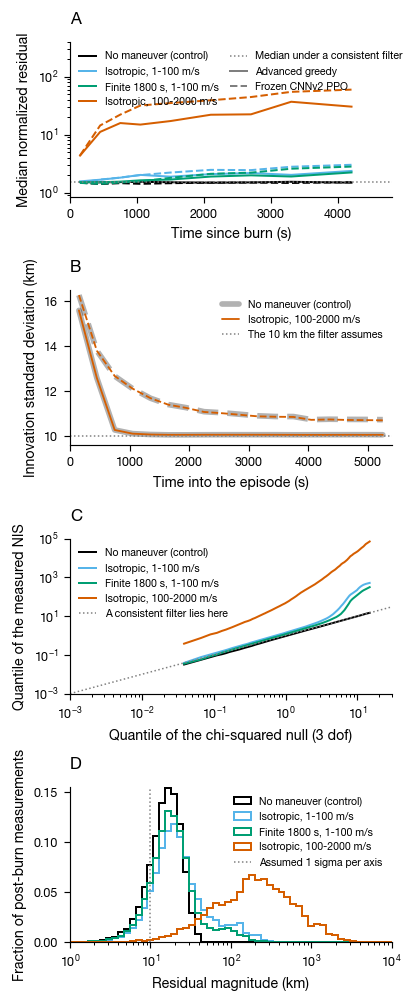

In [9]:
# Median of the chi distribution with 3 dof, the null for sqrt(NIS) under a consistent filter.
CHI3_MEDIAN = np.sqrt(2.3659738843)
ASSUMED_SIGMA_KM = 10.0

RESIDUAL_CONDITIONS = {
    "nullburn": (BLACK, "No maneuver (control)"),
    "random": (SKY, "Isotropic, 1-100 m/s"),
    "finite1800s": (GREEN, "Finite 1800 s, 1-100 m/s"),
    "stress100to2000": (VERMILION, "Isotropic, 100-2000 m/s"),
}
POLICY_STYLE = {"advanced_greedy": "-", "frozen_cnnv2_ppo": "--"}


def binned(x, y, edges, reducer=np.median, minimum=30):
    index = np.digitize(x, edges) - 1
    centres, values = [], []
    for bucket in range(len(edges) - 1):
        mask = index == bucket
        if mask.sum() >= minimum:
            centres.append(0.5 * (edges[bucket] + edges[bucket + 1]))
            values.append(reducer(y[mask]))
    return np.array(centres), np.array(values)


def post_burn(policy, condition, column):
    """One column of the residual table, restricted to measurements taken after the burn."""
    table = residuals(policy, condition)
    delay = table["seconds_after_burn"]
    return table[column][np.isfinite(delay) & (delay >= 0)]


fig, axes = plt.subplots(4, 1, figsize=(COLUMN_WIDTH, 8.4))

# --- A: the residual after the burn, against the null a consistent filter would give -------------
ax = axes[0]
burn_edges = np.array([0, 300, 600, 900, 1200, 1800, 2400, 3000, 3600, 4800])
for condition, (colour, label) in RESIDUAL_CONDITIONS.items():
    for policy, style in POLICY_STYLE.items():
        delay = post_burn(policy, condition, "seconds_after_burn")
        value = post_burn(policy, condition, "nis")
        keep = value > 0
        cx, cy = binned(delay[keep], np.sqrt(value[keep]), burn_edges)
        ax.plot(cx, cy, style, color=colour, linewidth=1.2,
                label=label if policy == "advanced_greedy" else None)
ax.axhline(CHI3_MEDIAN, color=GREY, linestyle=":", linewidth=0.9,
           label="Median under a consistent filter")
ax.set_yscale("log")
# Headroom so the two column legend clears the 100-2000 m/s curve.
ax.set_ylim(0.85, 400)
ax.set_xlim(0, 4800)
ax.set_xlabel("Time since burn (s)")
ax.set_ylabel("Median normalized residual")
# The policy is carried by line style, so it belongs in the legend rather than in a floating note.
style_keys = [plt.Line2D([], [], color=GREY, linestyle=style, linewidth=1.2, label=name)
              for style, name in (("-", "Advanced greedy"), ("--", "Frozen CNNv2 PPO"))]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + style_keys, labels + [line.get_label() for line in style_keys],
          loc="upper left", fontsize=6.3, handlelength=1.6, ncol=2, columnspacing=1.1)
panel_label(ax, "A")

# --- B: the standard deviation the filter assigns to its own residual ---------------------------
ax = axes[1]
time_edges = np.arange(0, 5401, 300)
# The control is a wide pale band so the coinciding treatment does not hide it.
for condition, width, alpha in (("nullburn", 3.4, 0.30), ("stress100to2000", 1.1, 1.0)):
    colour, label = RESIDUAL_CONDITIONS[condition]
    for policy, style in POLICY_STYLE.items():
        table = residuals(policy, condition)
        keep = table["nis"] > 0
        sigma = table["innovation_norm_km"][keep] / np.sqrt(table["nis"][keep])
        cx, cy = binned(table["time_seconds"][keep], sigma, time_edges)
        ax.plot(cx, cy, style, color=colour, linewidth=width, alpha=alpha,
                solid_capstyle="round",
                label=label if policy == "advanced_greedy" else None)
ax.axhline(ASSUMED_SIGMA_KM, color=GREY, linestyle=":", linewidth=0.9,
           label="The 10 km the filter assumes")
ax.set_xlim(0, 5400)
ax.set_ylim(9.6, 16.5)
ax.set_xlabel("Time into the episode (s)")
ax.set_ylabel("Innovation standard deviation (km)")
ax.legend(loc="upper right", fontsize=6.3, handlelength=1.6)
panel_label(ax, "B")

# --- C: is each arm the distribution the filter claims? -----------------------------------------
ax = axes[2]
quantiles = np.linspace(0.002, 0.998, 400)
try:
    from scipy.stats import chi2
    theoretical = chi2.ppf(quantiles, df=3)
except ImportError:                                   # keep the notebook runnable without scipy
    reference = np.sum(np.random.default_rng(0).normal(size=(400000, 3)) ** 2, axis=1)
    theoretical = np.quantile(reference, quantiles)
for condition, (colour, label) in RESIDUAL_CONDITIONS.items():
    pooled = np.concatenate([post_burn(policy, condition, "nis") for policy in POLICY_STYLE])
    ax.plot(theoretical, np.quantile(pooled, quantiles), color=colour, linewidth=1.2, label=label)
diagonal = np.array([1e-3, 1e5])
ax.plot(diagonal, diagonal, color=GREY, linestyle=":", linewidth=0.9,
        label="A consistent filter lies here")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(1e-3, 30); ax.set_ylim(1e-3, 1e5)
ax.set_xlabel("Quantile of the chi-squared null (3 dof)")
ax.set_ylabel("Quantile of the measured NIS")
ax.legend(loc="upper left", fontsize=6.3, handlelength=1.6)
panel_label(ax, "C")

# --- D: the residual in kilometres, against the noise floor -------------------------------------
ax = axes[3]
bins = np.logspace(0, 4, 55)
for condition, (colour, label) in RESIDUAL_CONDITIONS.items():
    pooled = np.concatenate([
        post_burn(policy, condition, "innovation_norm_km") for policy in POLICY_STYLE
    ])
    pooled = pooled[pooled > 0]
    ax.hist(pooled, bins=bins, histtype="step", color=colour, linewidth=1.2,
            weights=np.full(pooled.size, 1.0 / pooled.size), label=label)
ax.axvline(ASSUMED_SIGMA_KM, color=GREY, linestyle=":", linewidth=0.9,
           label="Assumed 1 sigma per axis")
ax.set_xscale("log")
ax.set_xlim(1, 1e4)
ax.set_ylim(0, 0.155)
ax.set_xlabel("Residual magnitude (km)")
ax.set_ylabel("Fraction of post-burn measurements")
ax.legend(loc="upper right", fontsize=6.3, handlelength=1.6)
panel_label(ax, "D")

fig.tight_layout()
save(fig, "fig7_residual_diagnostics")
plt.show()

## Figure 8

Per-sensor measurement residuals for a detectable burn and one at the noise floor, against the
standard deviation the filter assigns to them. This is the plot the scalar NIS cannot give,
because NIS discards the sign and the per-axis structure. Rows are the three components of the
measurement, columns are the two burn magnitudes, and the burn is at zero on the time axis.

200 m/s in-track: 2.74% of residuals fall outside the plotted range
    x: residual std  10.24 km before the burn,  62.56 km after
    y: residual std   9.91 km before the burn,  62.09 km after
    z: residual std  10.27 km before the burn,  39.58 km after
5 m/s in-track: 0.00% of residuals fall outside the plotted range
    x: residual std  10.24 km before the burn,  10.43 km after
    y: residual std   9.92 km before the burn,  10.15 km after
    z: residual std  10.27 km before the burn,  10.07 km after


saved fig8_measurement_residuals.png and fig8_measurement_residuals.pdf


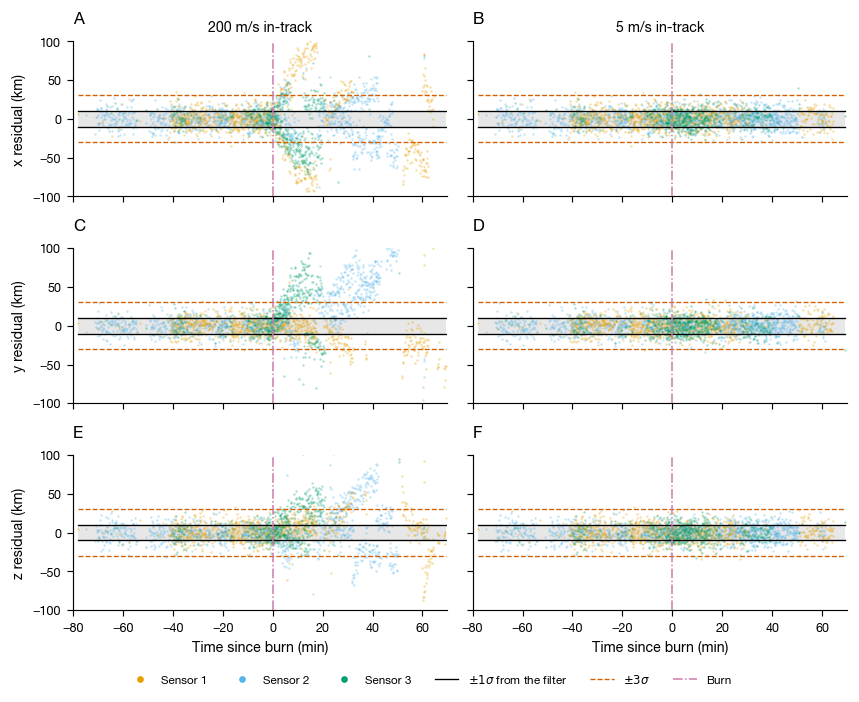

In [10]:
TRACES = PROJECT_ROOT / "results/residual_traces/cache"
RESIDUAL_POLICY = "advanced_greedy"
# 200 m/s sits well above the measured detection floor and 5 m/s well below it, both in-track.
TRACE_ARMS = [("alongtrack200mps", "200 m/s in-track"),
              ("alongtrack5mps", "5 m/s in-track")]
SENSOR_COLOUR = {"agent_0": ORANGE, "agent_1": SKY, "agent_2": GREEN}
RESIDUAL_LIMIT_KM = 100.0


def trace(policy, arm):
    path = TRACES / f"{policy}_{arm}_sigma10_10seeds.npz"
    table = dict(np.load(path))
    tagged = np.isfinite(table["seconds_after_burn"])
    return {key: value[tagged] for key, value in table.items()}


fig, axes = plt.subplots(3, 2, figsize=(DOUBLE_WIDTH, 5.6), sharex=True, sharey=True)

for column, (arm, arm_label) in enumerate(TRACE_ARMS):
    table = trace(RESIDUAL_POLICY, arm)
    minutes = table["seconds_after_burn"] / 60.0
    for row, axis in enumerate("xyz"):
        ax = axes[row, column]
        residual = table[f"innovation_{axis}_km"]
        # The filter's own sigma for this component, effectively sqrt(R) once P has collapsed.
        sigma = float(np.median(table[f"innovation_sigma_{axis}_km"]))
        span = np.array([minutes.min(), minutes.max()])
        ax.fill_between(span, -sigma, sigma, color=GREY, alpha=0.18, lw=0, zorder=0)
        for sign in (1, -1):
            ax.plot(span, [sign * sigma] * 2, color=BLACK, lw=0.8, zorder=2)
            ax.plot(span, [sign * 3 * sigma] * 2, color=VERMILION, lw=0.8, ls="--", zorder=2)
        for sensor, colour in SENSOR_COLOUR.items():
            keep = table["agent_id"] == sensor
            ax.scatter(minutes[keep], residual[keep], s=2, alpha=0.35, color=colour,
                       linewidths=0, zorder=1)
        ax.axvline(0, color=PURPLE, lw=0.9, ls="-.", zorder=3)
        if row == 0:
            ax.set_title(arm_label, pad=6)
        if column == 0:
            ax.set_ylabel(f"{axis} residual (km)")
        panel_label(ax, "ABCDEF"[row * 2 + column])

    outside = np.mean([
        np.mean(np.abs(table[f"innovation_{axis}_km"]) > RESIDUAL_LIMIT_KM) for axis in "xyz"
    ])
    print(f"{arm_label}: {100 * outside:.2f}% of residuals fall outside the plotted range")
    for axis in "xyz":
        before = table[f"innovation_{axis}_km"][table["seconds_after_burn"] < 0].std()
        after = table[f"innovation_{axis}_km"][table["seconds_after_burn"] >= 0].std()
        print(f"    {axis}: residual std {before:6.2f} km before the burn, {after:6.2f} km after")

axes[0, 0].set_ylim(-RESIDUAL_LIMIT_KM, RESIDUAL_LIMIT_KM)
axes[0, 0].set_xlim(-80, 70)
for ax in axes[2]:
    ax.set_xlabel("Time since burn (min)")

handles = [plt.Line2D([], [], marker="o", ls="", ms=3, color=colour, label=f"Sensor {index + 1}")
           for index, colour in enumerate(SENSOR_COLOUR.values())]
handles += [plt.Line2D([], [], color=BLACK, lw=0.8, label="$\\pm1\\sigma$ from the filter"),
            plt.Line2D([], [], color=VERMILION, lw=0.8, ls="--", label="$\\pm3\\sigma$"),
            plt.Line2D([], [], color=PURPLE, lw=0.9, ls="-.", label="Burn")]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=7,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

fig.tight_layout()
save(fig, "fig8_measurement_residuals")
plt.show()

## Figure 9

The whitened innovation against the standard normal it should follow. Whitening uses the Cholesky
factor of the full innovation covariance, not its diagonal, so the sum of the squared components
is NIS exactly. Panel A asks whether the distribution is the one the filter assumes. Panel B
separates the two ways it can fail, a shift of the mean and a growth of the spread.

No maneuver                n=  66069  mean=+0.001  sd=0.989
200 m/s, after the burn    n=   3837  mean=+0.890  sd=4.614
5 m/s, after the burn      n=   4326  mean=+0.021  sd=0.995


saved fig9_whitened_innovation.png and fig9_whitened_innovation.pdf


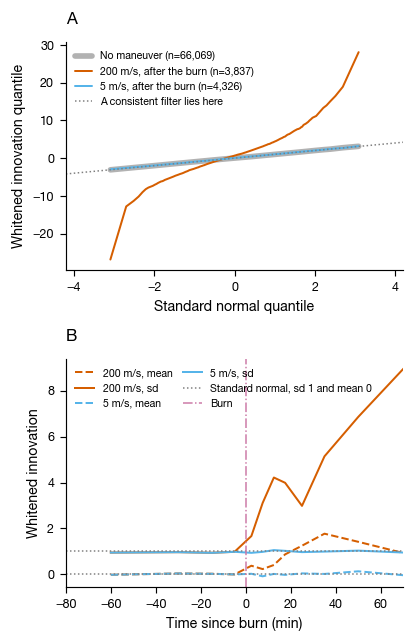

In [11]:
def whitened(policy, arm):
    """Whitened innovation components with their maneuver labels, one row per component."""
    table = trace_all(policy, arm)
    stacked = np.concatenate([table[f"whitened_{axis}"] for axis in "xyz"])
    delay = np.tile(table["seconds_after_burn"], 3)
    return stacked, delay


def trace_all(policy, arm):
    """Every record, tagged or not. Figure 8 keeps only the tagged ones; the null needs the rest."""
    return dict(np.load(TRACES / f"{policy}_{arm}_sigma10_10seeds.npz"))


# The null is the 80 never-burning objects per episode, pooled over both arms.
null = np.concatenate([whitened(RESIDUAL_POLICY, arm)[0][
    ~np.isfinite(whitened(RESIDUAL_POLICY, arm)[1])] for arm, _ in TRACE_ARMS])
POPULATIONS = [("No maneuver", BLACK, null)]
for (arm, arm_label), colour in zip(TRACE_ARMS, (VERMILION, SKY)):
    values, delay = whitened(RESIDUAL_POLICY, arm)
    keep = np.isfinite(delay) & (delay >= 0)
    magnitude = " ".join(arm_label.split()[:2])
    POPULATIONS.append((f"{magnitude}, after the burn", colour, values[keep]))

fig, axes = plt.subplots(2, 1, figsize=(COLUMN_WIDTH, 5.4))

# --- A: is it the distribution the filter assumes? ---------------------------------------------
ax = axes[0]
quantiles = np.linspace(0.001, 0.999, 400)
try:
    from scipy.stats import norm
    theoretical = norm.ppf(quantiles)
except ImportError:                                   # keep the notebook runnable without scipy
    reference = np.random.default_rng(0).normal(size=400000)
    theoretical = np.quantile(reference, quantiles)
for index, (label, colour, values) in enumerate(POPULATIONS):
    width, alpha = (3.4, 0.30) if index == 0 else (1.2, 1.0)
    ax.plot(theoretical, np.quantile(values, quantiles), color=colour, linewidth=width,
            alpha=alpha, solid_capstyle="round", label=f"{label} (n={values.size:,})")
    print(f"{label:26s} n={values.size:7d}  mean={values.mean():+.3f}  sd={values.std():.3f}")
diagonal = np.array([-4.2, 4.2])
ax.plot(diagonal, diagonal, color=GREY, linestyle=":", linewidth=0.9,
        label="A consistent filter lies here")
ax.set_xlim(-4.2, 4.2)
ax.set_xlabel("Standard normal quantile")
ax.set_ylabel("Whitened innovation quantile")
ax.legend(loc="upper left", fontsize=6.3, handlelength=1.6)
panel_label(ax, "A")

# --- B: a shifted mean or a widened spread? ----------------------------------------------------
ax = axes[1]
delay_edges = np.array([-4800, -2400, -1200, -600, 0, 300, 600, 900, 1200, 1800, 2400, 3600, 4800])
for (arm, arm_label), colour in zip(TRACE_ARMS, (VERMILION, SKY)):
    values, delay = whitened(RESIDUAL_POLICY, arm)
    keep = np.isfinite(delay)
    short = " ".join(arm_label.split()[:2])
    for statistic, style, name in ((np.mean, "--", "mean"), (np.std, "-", "sd")):
        cx, cy = binned(delay[keep] / 60.0, values[keep], delay_edges / 60.0,
                        reducer=statistic, minimum=50)
        ax.plot(cx, cy, style, color=colour, linewidth=1.2, label=f"{short}, {name}")
ax.axhline(1.0, color=GREY, linestyle=":", linewidth=0.9, label="Standard normal, sd 1 and mean 0")
ax.axhline(0.0, color=GREY, linestyle=":", linewidth=0.9)
ax.axvline(0, color=PURPLE, linewidth=0.9, linestyle="-.", label="Burn")
ax.set_xlim(-80, 70)
ax.set_xlabel("Time since burn (min)")
ax.set_ylabel("Whitened innovation")
ax.legend(loc="upper left", fontsize=6.3, handlelength=1.8, ncol=2, columnspacing=1.0)
panel_label(ax, "B")

fig.tight_layout()
save(fig, "fig9_whitened_innovation")
plt.show()

## Discussion figure

The quantity the reward is built from and the truth-ledger tracking error of the same
tagged objects on one clock, for talks rather than the paper. Reads
`paper_cache/error_history.npz`, built by `build_paper_figure_cache.py`, and writes to
`figures_discussion` at presentation size.

saved fig_mechanism_proxy_vs_objective.png and fig_mechanism_proxy_vs_objective.pdf to figures_discussion


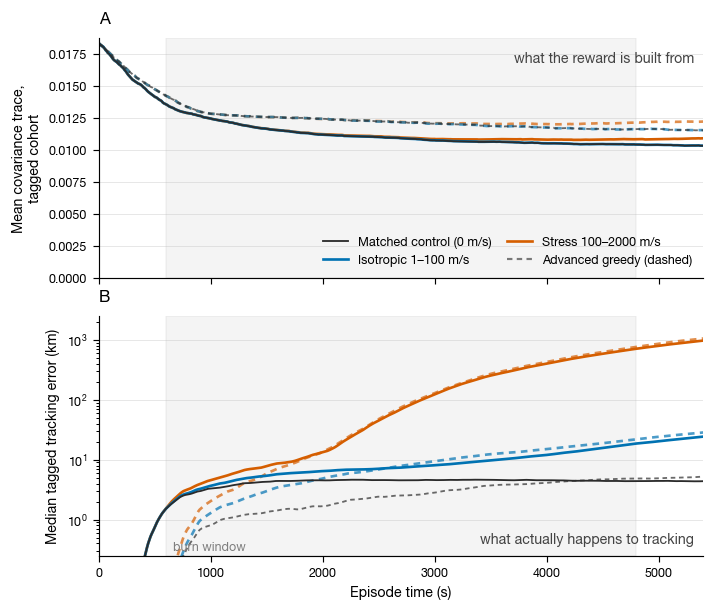

In [12]:
DISCUSSION = GRID / "figures_discussion"
DISCUSSION.mkdir(parents=True, exist_ok=True)
error_history = np.load(CACHE / "error_history.npz")


def save_discussion(fig, name):
    for extension in ("png", "pdf"):
        fig.savefig(DISCUSSION / f"{name}.{extension}", dpi=400)
    print(f"saved {name}.png and {name}.pdf to figures_discussion")


DARK = "#2B2B2B"
# Control drawn last so it stays visible where the curves coincide.
MECHANISM_CONDITIONS = [
    ("stress100to2000", "Stress 100–2000 m/s", VERMILION, 1.6),
    ("random", "Isotropic 1–100 m/s", BLUE, 1.6),
    ("nullburn", "Matched control (0 m/s)", DARK, 1.1),
]

fig, axes = plt.subplots(2, 1, figsize=(6.5, 5.6), sharex=True,
                         gridspec_kw={"hspace": 0.16})
for ax in axes:
    ax.axvspan(600, 4800, color=GREY, alpha=0.08, zorder=0)
    ax.grid(True, axis="y")

covariance_time = history["frozen_cnnv2_ppo|nullburn|time_seconds"]
error_time = error_history["frozen_cnnv2_ppo|nullburn|time_seconds"]
for condition, label, colour, width in MECHANISM_CONDITIONS:
    axes[0].plot(covariance_time, history[f"advanced_greedy|{condition}|mean_tagged"],
                 color=colour, linestyle=(0, (2.5, 2)), alpha=0.7, lw=width)
    axes[0].plot(covariance_time, history[f"frozen_cnnv2_ppo|{condition}|mean_tagged"],
                 color=colour, label=label, lw=width)
    axes[1].plot(error_time, error_history[f"advanced_greedy|{condition}|median_tagged_error_km"],
                 color=colour, linestyle=(0, (2.5, 2)), alpha=0.7, lw=width)
    axes[1].plot(error_time, error_history[f"frozen_cnnv2_ppo|{condition}|median_tagged_error_km"],
                 color=colour, lw=width)

axes[0].set_ylabel("Mean covariance trace,\ntagged cohort")
axes[0].set_ylim(bottom=0)
axes[1].set_yscale("log")
axes[1].set_ylim(0.25, 2500)
axes[1].set_ylabel("Median tagged tracking error (km)")
axes[1].set_xlabel("Episode time (s)")
axes[1].set_xlim(0, 5400)

for ax, letter in zip(axes, "AB"):
    panel_label(ax, letter, dy=7)

axes[0].annotate("what the reward is built from", xy=(0.985, 0.9),
                 xycoords="axes fraction", ha="right", fontsize=8.5,
                 style="italic", color="#444444")
axes[1].annotate("what actually happens to tracking", xy=(0.985, 0.05),
                 xycoords="axes fraction", ha="right", fontsize=8.5,
                 style="italic", color="#444444")
axes[1].annotate("burn window", xy=(660, 0.31), ha="left", fontsize=7.5, color=GREY)

handles, labels = axes[0].get_legend_handles_labels()
handles, labels = handles[::-1], labels[::-1]
handles.append(mpl.lines.Line2D([], [], color="#444444", linestyle=(0, (2.5, 2)), alpha=0.7))
labels.append("Advanced greedy (dashed)")
axes[0].legend(handles, labels, loc="lower right", ncol=2, columnspacing=1.2)

save_discussion(fig, "fig_mechanism_proxy_vs_objective")
plt.show()

## What was written

A check on the output directory.

In [14]:
for path in sorted(FIGURES.iterdir()):
    print(f"{path.name:44s} {path.stat().st_size / 1024:8.1f} kB")

fig1_covariance_history.pdf                      23.5 kB
fig1_covariance_history.png                     299.7 kB
fig2_paired_change_from_control.pdf              21.1 kB
fig2_paired_change_from_control.png             282.3 kB
fig3_innovation_detection.pdf                    26.6 kB
fig3_innovation_detection.png                   341.1 kB
fig4_dose_response.pdf                          187.0 kB
fig4_dose_response.png                          789.9 kB
fig5_custody_geometry.pdf                       146.9 kB
fig5_custody_geometry.png                       693.8 kB
fig6_covariance_ceiling.pdf                      18.7 kB
fig6_covariance_ceiling.png                     151.5 kB
fig7_residual_diagnostics.pdf                    30.1 kB
fig7_residual_diagnostics.png                   708.0 kB
fig8_measurement_residuals.pdf                  177.5 kB
fig8_measurement_residuals.png                 1542.8 kB
fig9_whitened_innovation.pdf                     21.4 kB
fig9_whitened_innovation.png   